# EEG Biometric Authentication — Riemannian Potato (sessions 1230–1600)

**Data**: all interim sessions from 1230 to 1600 (excluding 2000), 10 Hz and 15 Hz only

| Session | Subject | Rates available |
|---------|---------|----------------|
| 1230    | ziyang  | 10 Hz, 15 Hz |
| 1400    | ziyang  | 10 Hz, 15 Hz |
| 1400    | chris   | 10 Hz, 15 Hz |
| 1600    | chris   | 10 Hz |
| 1600    | josua   | 10 Hz |

**Protocol**: enroll ziyang on 1230, cross-validate against all other sessions/subjects.

In [1]:
import sys; sys.path.insert(0, '/home/josua/Projects/hackathon_zeiss/brain_id')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import welch
from riemann_potato import (load_csv, preprocess, epoch, to_covs,
                            enroll_multi, verify_multi,
                            OCC_CHANNELS, RATE_TO_FREQ, SFREQ, SFREQ_DS,
                            save_potatoes, load_potatoes)

INTERIM = '../data/interim/'
INTERIM_10HZ = '../data/interim/10hz/'

# All sessions 1230-1600 (excluding 2000, excluding 5hz)
ALL_DATA = {
    ('ziyang', '1230', '10hz'): f'{INTERIM_10HZ}1230_ziyang_10hz.csv',
    ('ziyang', '1230', '15hz'): f'{INTERIM}1230_ziyang_15hz.csv',
    ('ziyang', '1400', '10hz'): f'{INTERIM_10HZ}1400_ziyang_10hz.csv',
    ('ziyang', '1400', '15hz'): f'{INTERIM}1400_ziyang_15hz.csv',
    ('chris',  '1400', '10hz'): f'{INTERIM_10HZ}1400_chris_10hz.csv',
    ('chris',  '1400', '15hz'): f'{INTERIM}1400_chris_15hz.csv',
    ('chris',  '1600', '10hz'): f'{INTERIM_10HZ}1600_chris_10hz.csv',
    ('josua',  '1600', '10hz'): f'{INTERIM_10HZ}1600_josua_10hz.csv',
}

SUBJECT_COLORS = {'ziyang': '#1565C0', 'chris': '#EF5350', 'josua': '#2E7D32'}
print(f'Loaded {len(ALL_DATA)} recordings')
for k, v in ALL_DATA.items():
    print(f"  {k[1]} {k[0]:8s} {k[2]:5s}  {v.split('/')[-1]}")

Loaded 8 recordings
  1230 ziyang   10hz   1230_ziyang_10hz.csv
  1230 ziyang   15hz   1230_ziyang_15hz.csv
  1400 ziyang   10hz   1400_ziyang_10hz.csv
  1400 ziyang   15hz   1400_ziyang_15hz.csv
  1400 chris    10hz   1400_chris_10hz.csv
  1400 chris    15hz   1400_chris_15hz.csv
  1600 chris    10hz   1600_chris_10hz.csv
  1600 josua    10hz   1600_josua_10hz.csv


## 1. Raw signal snippets — all sessions 1230–1600

Occipital channel Oz (ch7, index 6 of raw 8). 5 seconds shown.

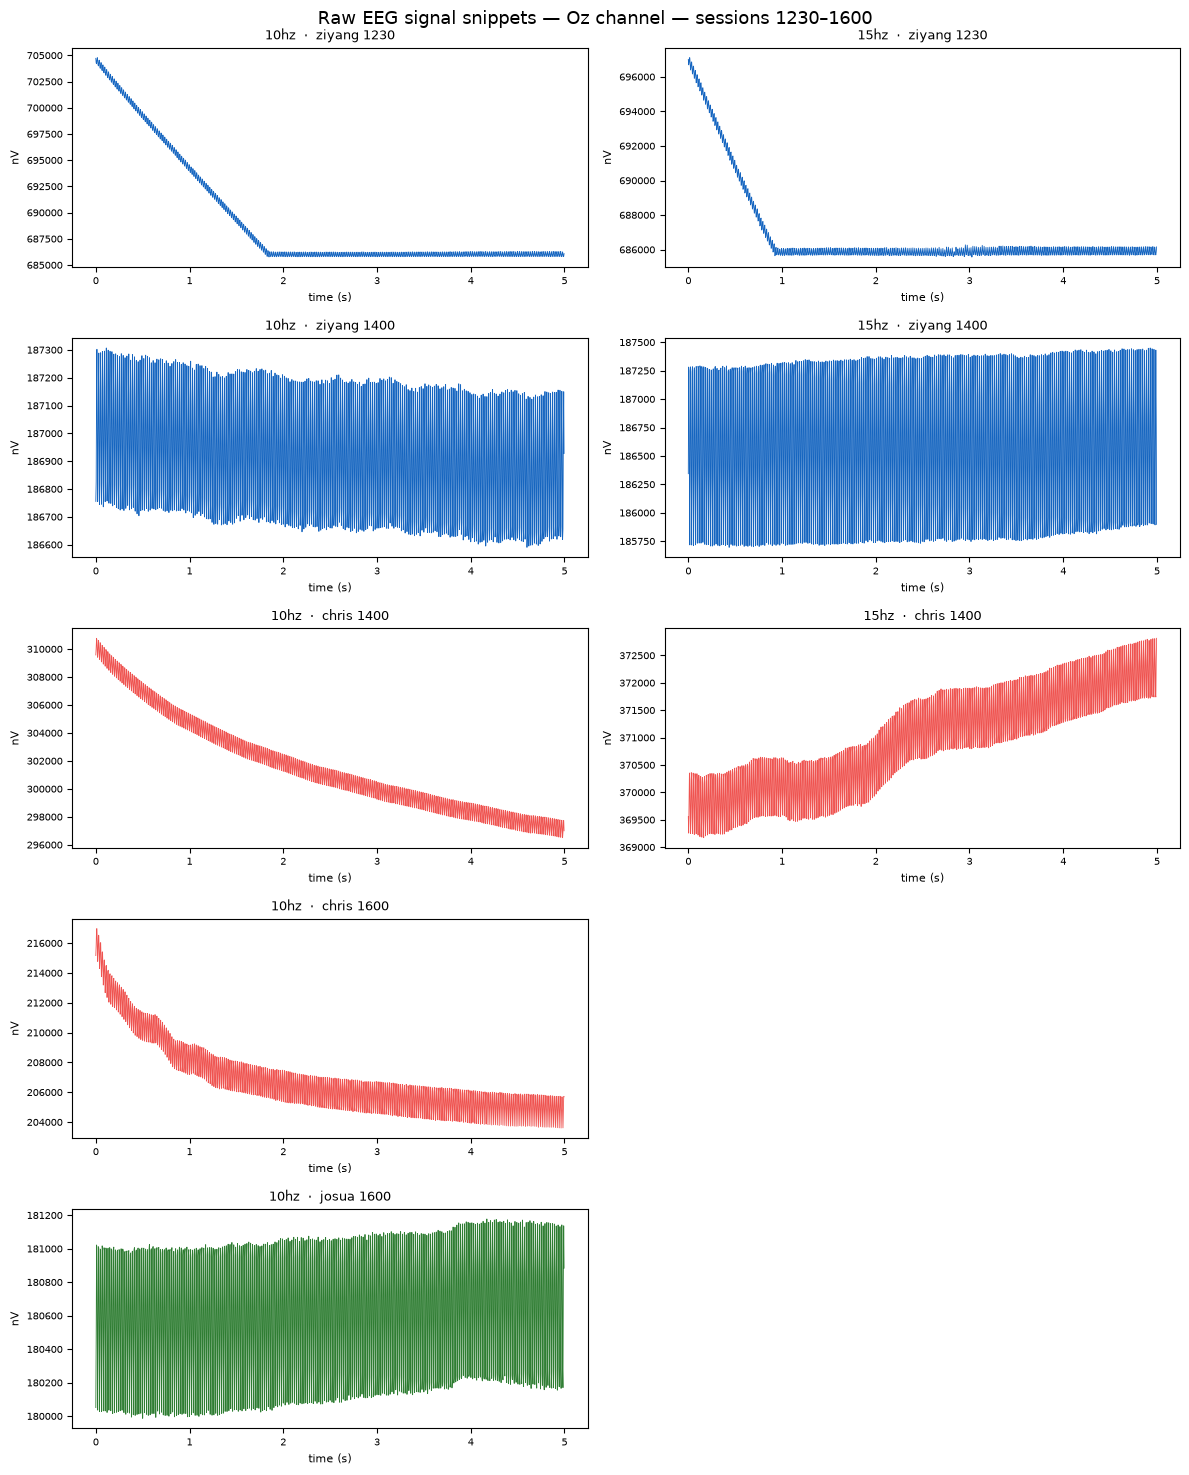

In [2]:
SNIPPET_SEC = 5
OZ_IDX = 6  # Oz = ch7 (0-based raw index)

rates = ['10hz', '15hz']
rate_entries = {r: [(s, ses) for (s, ses, rr) in ALL_DATA if rr == r] for r in rates}

n_rows = max(len(e) for e in rate_entries.values())
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 3 * n_rows), sharex=False)
fig.suptitle('Raw EEG signal snippets — Oz channel — sessions 1230–1600', fontsize=13)

for col, rate in enumerate(rates):
    entries = rate_entries[rate]
    for row, (subject, session) in enumerate(entries):
        ax = axes[row][col]
        path = ALL_DATA[(subject, session, rate)]
        X = load_csv(path)
        oz = X[OZ_IDX]
        t = np.arange(SNIPPET_SEC * SFREQ) / SFREQ
        ax.plot(t, oz[:len(t)], color=SUBJECT_COLORS[subject], linewidth=0.6)
        ax.set_title(f'{rate}  ·  {subject} {session}', fontsize=9)
        ax.set_xlabel('time (s)', fontsize=8)
        ax.set_ylabel('nV', fontsize=8)
        ax.tick_params(labelsize=7)
    for row in range(len(entries), n_rows):
        axes[row][col].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/01_signal_snippets_1230_1600.png', dpi=150)
plt.show()

## 2. Power spectral density — all sessions 1230–1600

One PSD per recording using Welch's method (Oz channel). SSVEP peaks should be visible at the stimulus frequency.

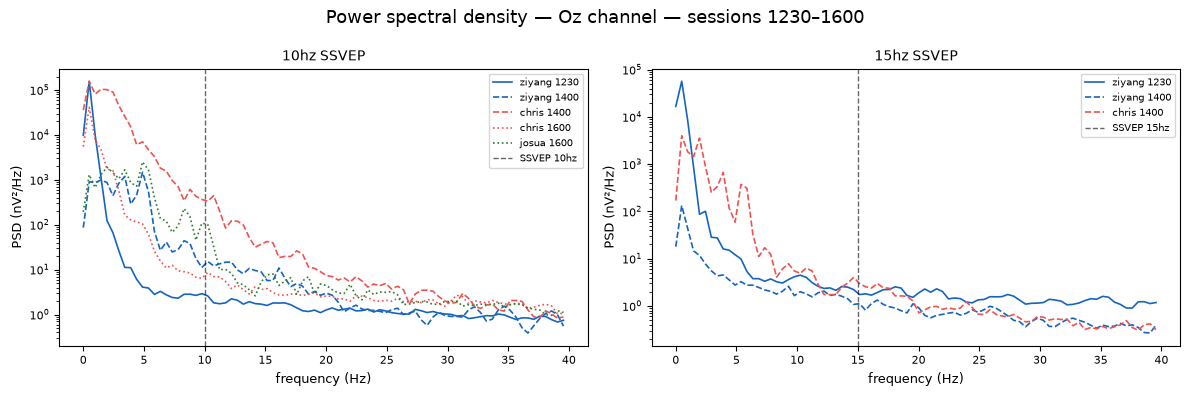

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
fig.suptitle('Power spectral density — Oz channel — sessions 1230–1600', fontsize=13)

rate_freqs = {'10hz': 10.0, '15hz': 15.0}
linestyles = {'1230': '-', '1400': '--', '1600': ':'}

for col, rate in enumerate(rates):
    ax = axes[col]
    for subject, session in rate_entries[rate]:
        path = ALL_DATA[(subject, session, rate)]
        X = load_csv(path)
        oz = X[OZ_IDX]
        f, pxx = welch(oz, fs=SFREQ, nperseg=512)
        mask = f <= 40
        ax.semilogy(f[mask], pxx[mask],
                    color=SUBJECT_COLORS[subject],
                    linestyle=linestyles[session],
                    linewidth=1.2,
                    label=f'{subject} {session}')
    ax.axvline(rate_freqs[rate], color='black', linewidth=1, linestyle='--', alpha=0.6,
               label=f'SSVEP {rate}')
    ax.set_title(f'{rate} SSVEP', fontsize=10)
    ax.set_xlabel('frequency (Hz)', fontsize=9)
    ax.set_ylabel('PSD (nV²/Hz)', fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/02_psd_1230_1600.png', dpi=150)
plt.show()

## 3. Enroll — Riemannian Potatoes per subject

- **ziyang**: enrolled on 1230 (10 Hz, 15 Hz)  
- **chris**: enrolled on 1400 (10 Hz, 15 Hz) — earliest session with multi-rate coverage  
- **josua**: enrolled on 1600 10 Hz (only session available)

In [4]:
ENROLL_SETS = {
    'ziyang': {
        '10hz': f'{INTERIM_10HZ}1230_ziyang_10hz.csv',
        '15hz': f'{INTERIM}1230_ziyang_15hz.csv',
    },
    'chris': {
        '10hz': f'{INTERIM_10HZ}1400_chris_10hz.csv',
        '15hz': f'{INTERIM}1400_chris_15hz.csv',
    },
    'josua': {
        '10hz': f'{INTERIM_10HZ}1600_josua_10hz.csv',
    },
}

all_potatoes = {}
for subject, rate_csvs in ENROLL_SETS.items():
    print(f'=== Enrolling {subject} ===')
    all_potatoes[subject] = enroll_multi(rate_csvs)
    print()

save_potatoes(all_potatoes, '../models/potato_pipelines_1230_1600.pkl')
print('All potatoes saved.')

=== Enrolling ziyang ===
  enrollment: 125 clean epochs  [1230_ziyang_10hz.csv]
  enrollment: 127 clean epochs  [1230_ziyang_15hz.csv]

=== Enrolling chris ===


  enrollment: 136 clean epochs  [1400_chris_10hz.csv]
  enrollment: 127 clean epochs  [1400_chris_15hz.csv]

=== Enrolling josua ===
  enrollment: 78 clean epochs  [1600_josua_10hz.csv]

Saved ['ziyang', 'chris', 'josua'] → ../models/potato_pipelines_1230_1600.pkl
All potatoes saved.


## 4. Cross-verify — all subjects × all sessions

For each enrolled subject's potato, run every available recording through it.  
- Same subject, different session → should **ACCEPT** (FRR test)  
- Different subject → should **REJECT** (FAR test)

In [5]:
from riemann_potato import verify, RATE_TO_FREQ

results = {}   # {enrolled_subject: {(test_subject, session, rate): result_dict}}

for enrolled in all_potatoes:
    results[enrolled] = {}
    potatoes = all_potatoes[enrolled]
    for (test_subj, session, rate), path in ALL_DATA.items():
        if rate not in potatoes:
            continue
        r = verify(potatoes[rate], path, ssvep_freq=RATE_TO_FREQ[rate])
        results[enrolled][(test_subj, session, rate)] = r

# Print as table
rows = []
for enrolled, entries in results.items():
    for (test_subj, session, rate), r in entries.items():
        is_self = (test_subj == enrolled)
        rows.append({
            'enrolled':    enrolled,
            'test_subject': test_subj,
            'session':     session,
            'rate':        rate,
            'is_self':     is_self,
            'decision':    r['decision'],
            'accept_rate': r['accept_rate'],
            'mean_zscore': r['mean_zscore'],
            'n_epochs':    r['n_epochs'],
        })

df = pd.DataFrame(rows)

def color_row(row):
    correct = (row['decision'] == 'ACCEPT') == row['is_self']
    bg = '#c8e6c9' if correct else '#ffcdd2'
    return [f'background-color: {bg}'] * len(row)

df.style.apply(color_row, axis=1)

,enrolled,test_subject,session,rate,is_self,decision,accept_rate,mean_zscore,n_epochs
0,ziyang,ziyang,1230,10hz,True,ACCEPT,0.992000,0.022000,125
1,ziyang,ziyang,1230,15hz,True,ACCEPT,0.961000,0.141000,127
2,ziyang,ziyang,1400,10hz,True,ACCEPT,0.708000,1.763000,65
3,ziyang,ziyang,1400,15hz,True,ACCEPT,0.667000,2.117000,63
4,ziyang,chris,1400,10hz,False,REJECT,0.485000,2.592000,136
5,ziyang,chris,1400,15hz,False,ACCEPT,0.606000,2.275000,127
6,ziyang,chris,1600,10hz,False,ACCEPT,0.853000,2.117000,75
7,ziyang,josua,1600,10hz,False,ACCEPT,0.615000,2.272000,78
8,chris,ziyang,1230,10hz,False,ACCEPT,0.656000,2.386000,125
9,chris,ziyang,1230,15hz,False,ACCEPT,0.528000,2.453000,127


## 5. Z-score distributions per enrolled subject

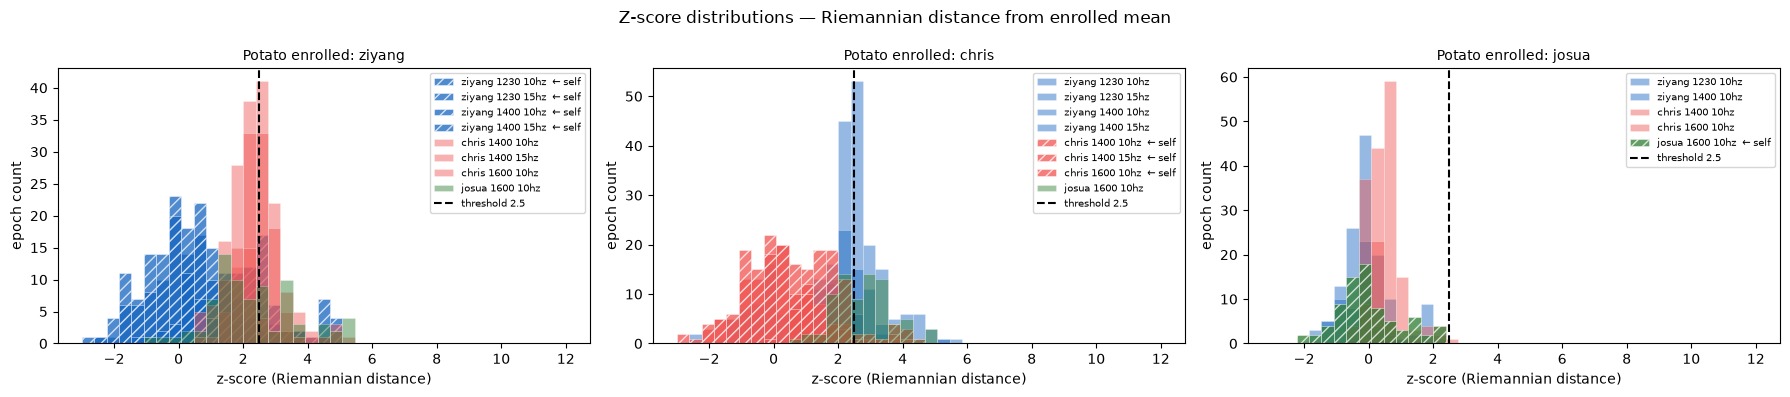

In [6]:
from riemann_potato import preprocess, load_csv, epoch, to_covs, OCC_CHANNELS, RATE_TO_FREQ

enrolled_subjects = list(all_potatoes.keys())
n_enrolled = len(enrolled_subjects)
fig, axes = plt.subplots(1, n_enrolled, figsize=(6 * n_enrolled, 4))
if n_enrolled == 1:
    axes = [axes]
fig.suptitle('Z-score distributions — Riemannian distance from enrolled mean', fontsize=12)
bins = np.linspace(-3, 12, 40)

for ax, enrolled in zip(axes, enrolled_subjects):
    potatoes = all_potatoes[enrolled]
    ax.set_title(f'Potato enrolled: {enrolled}', fontsize=10)
    for (test_subj, session, rate), path in ALL_DATA.items():
        if rate not in potatoes:
            continue
        ssvep_freq = RATE_TO_FREQ[rate]
        X = preprocess(load_csv(path, OCC_CHANNELS), ssvep_freq)
        covs = to_covs(epoch(X))
        z = potatoes[rate].transform(covs).ravel()
        is_self = (test_subj == enrolled)
        color = SUBJECT_COLORS[test_subj]
        hatch = '///' if is_self else ''
        alpha = 0.75 if is_self else 0.45
        label = f'{test_subj} {session} {rate}{"  ← self" if is_self else ""}'
        ax.hist(z, bins=bins, alpha=alpha, color=color, hatch=hatch,
                label=label, edgecolor='white', linewidth=0.4)
    ax.axvline(2.5, color='black', linewidth=1.5, linestyle='--', label='threshold 2.5')
    ax.set_xlabel('z-score (Riemannian distance)')
    ax.set_ylabel('epoch count')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../reports/figures/03_zscore_1230_1600.png', dpi=150)
plt.show()

## 6. Accept rates — all subjects × all rates

One bar per (test_subject, session, rate) grouped by enrolled potato.  
Green = correct decision; red = error.

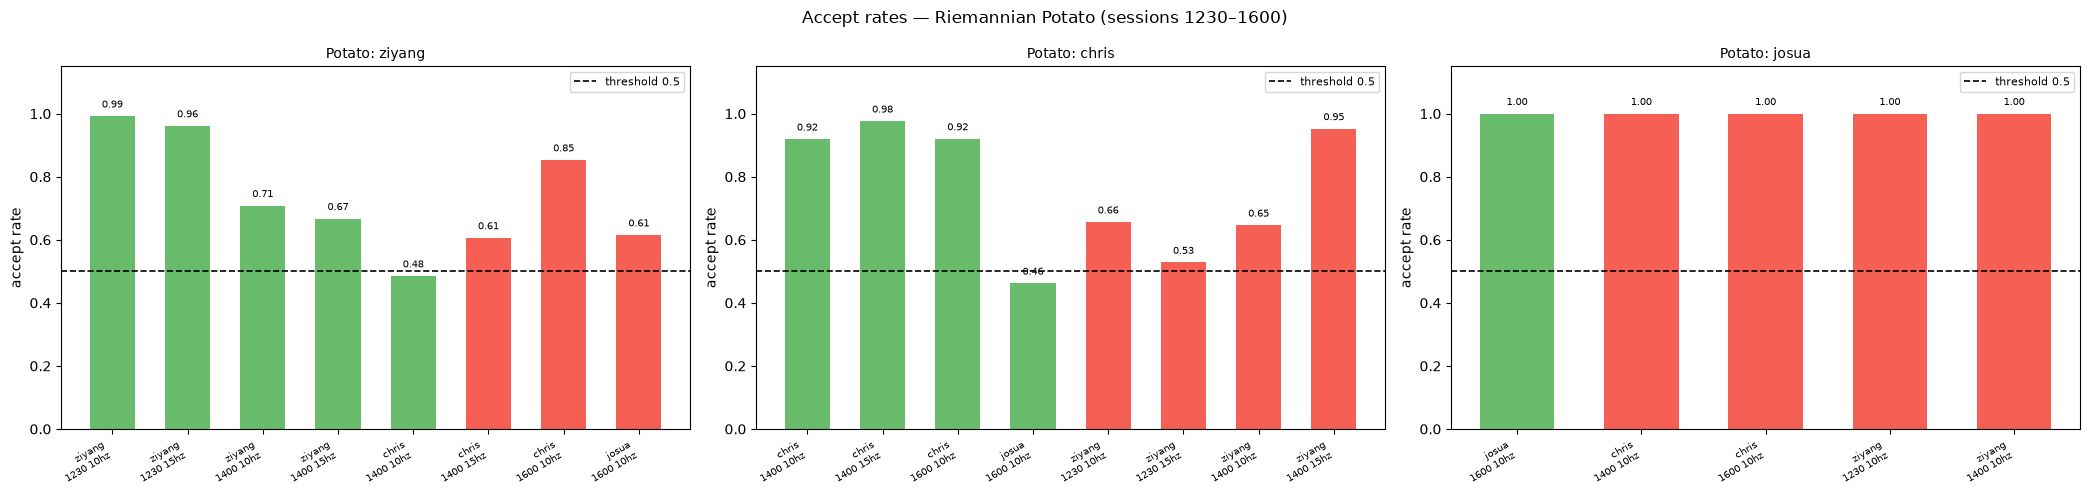

In [7]:
fig, axes = plt.subplots(1, n_enrolled, figsize=(7 * n_enrolled, 5))
if n_enrolled == 1:
    axes = [axes]
fig.suptitle('Accept rates — Riemannian Potato (sessions 1230–1600)', fontsize=12)

for ax, enrolled in zip(axes, enrolled_subjects):
    potatoes = all_potatoes[enrolled]
    sub_results = results[enrolled]
    # Collect items for this potato (sort: self first, then impostors)
    items = sorted(sub_results.items(), key=lambda x: (x[0][0] != enrolled, x[0]))
    labels = [f'{s}\n{ses} {r}' for (s, ses, r), _ in items]
    vals   = [v['accept_rate'] for _, v in items]
    colors_bar = []
    for (s, ses, r), v in items:
        is_self = (s == enrolled)
        correct = (v['decision'] == 'ACCEPT') == is_self
        colors_bar.append('#4CAF50' if correct else '#F44336')

    x = np.arange(len(labels))
    bars = ax.bar(x, vals, color=colors_bar, alpha=0.85, width=0.6)
    ax.axhline(0.5, color='black', linewidth=1.2, linestyle='--', label='threshold 0.5')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=30, ha='right')
    ax.set_ylabel('accept rate')
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Potato: {enrolled}', fontsize=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                ha='center', va='bottom', fontsize=7)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/04_accept_rates_1230_1600.png', dpi=150)
plt.show()

## 7. Same-session comparison

Split each recording at the midpoint: **first half → enroll**, **second half → self-test**.  
Impostor = other subject recorded in the same session (identical conditions).

| Session | Enrolled | Impostor | Rates |
|---------|----------|----------|-------|
| 1400    | ziyang   | chris    | 10 Hz, 15 Hz |
| 1400    | chris    | ziyang   | 10 Hz, 15 Hz |
| 1600    | chris    | josua    | 10 Hz |
| 1600    | josua    | chris    | 10 Hz |

In [8]:
from riemann_potato import enroll_from_array, verify_from_array

SAME_SESSION_PAIRS = [
    # (session, subject_a, subject_b, rates)
    ('1400', 'ziyang', 'chris', ['10hz', '15hz']),
    ('1600', 'chris',  'josua', ['10hz']),
]

PATHS = {
    ('ziyang', '1400', '10hz'): f'{INTERIM_10HZ}1400_ziyang_10hz.csv',
    ('ziyang', '1400', '15hz'): f'{INTERIM}1400_ziyang_15hz.csv',
    ('chris',  '1400', '10hz'): f'{INTERIM_10HZ}1400_chris_10hz.csv',
    ('chris',  '1400', '15hz'): f'{INTERIM}1400_chris_15hz.csv',
    ('chris',  '1600', '10hz'): f'{INTERIM_10HZ}1600_chris_10hz.csv',
    ('josua',  '1600', '10hz'): f'{INTERIM_10HZ}1600_josua_10hz.csv',
}

def split_half(path, ssvep_freq):
    X = load_csv(path, OCC_CHANNELS)
    mid = X.shape[1] // 2
    return preprocess(X[:, :mid], ssvep_freq), preprocess(X[:, mid:], ssvep_freq)

rows = []
for session, subj_a, subj_b, rates in SAME_SESSION_PAIRS:
    for subj_enroll, subj_imp in [(subj_a, subj_b), (subj_b, subj_a)]:
        for rate in rates:
            ssvep_freq = RATE_TO_FREQ[rate]
            enroll_path = PATHS[(subj_enroll, session, rate)]
            imp_path    = PATHS[(subj_imp,    session, rate)]

            X_enroll_half, X_self_half = split_half(enroll_path, ssvep_freq)
            X_imp, _                   = split_half(imp_path, ssvep_freq)

            potato = enroll_from_array(X_enroll_half, ssvep_freq)
            self_r = verify_from_array(potato, X_self_half, ssvep_freq)
            imp_r  = verify_from_array(potato, X_imp,       ssvep_freq)

            for label, r, is_self in [('self', self_r, True), ('impostor', imp_r, False)]:
                correct = (r['decision'] == 'ACCEPT') == is_self
                rows.append({
                    'session':   session,
                    'enrolled':  subj_enroll,
                    'tested':    subj_enroll if is_self else subj_imp,
                    'rate':      rate,
                    'type':      label,
                    'decision':  r['decision'],
                    'accept_rate': r['accept_rate'],
                    'mean_zscore': r['mean_zscore'],
                    'n_epochs':  r['n_epochs'],
                    'correct':   correct,
                })

df_ss = pd.DataFrame(rows)

def color_correct(row):
    bg = '#c8e6c9' if row['correct'] else '#ffcdd2'
    return [f'background-color: {bg}'] * len(row)

df_ss.style.apply(color_correct, axis=1)

  enrollment: 12 clean epochs
  enrollment: 11 clean epochs
  enrollment: 26 clean epochs
  enrollment: 24 clean epochs


  enrollment: 14 clean epochs
  enrollment: 14 clean epochs


,session,enrolled,tested,rate,type,decision,accept_rate,mean_zscore,n_epochs,correct
0,1400,ziyang,ziyang,10hz,self,ACCEPT,1.000000,0.866000,12,True
1,1400,ziyang,chris,10hz,impostor,ACCEPT,0.923000,1.564000,26,False
2,1400,ziyang,ziyang,15hz,self,REJECT,0.000000,2.645000,11,False
3,1400,ziyang,chris,15hz,impostor,REJECT,0.375000,2.433000,24,True
4,1400,chris,chris,10hz,self,REJECT,0.000000,7.767000,26,False
5,1400,chris,ziyang,10hz,impostor,REJECT,0.000000,7.263000,12,True
6,1400,chris,chris,15hz,self,REJECT,0.000000,5.596000,24,False
7,1400,chris,ziyang,15hz,impostor,REJECT,0.000000,4.568000,11,True
8,1600,chris,chris,10hz,self,ACCEPT,1.000000,0.713000,14,True
9,1600,chris,josua,10hz,impostor,ACCEPT,0.786000,2.336000,14,False
